## Trabajo Práctico $\mathbb{II}$
Inferencia y Estimación

In [20]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from huffman_code import huffman_code # código provisto por la cátedra

filepath = Path('text_examples') 

strings = [] # lista con los textos de ejemplo
for file in filepath.glob('*.txt'):
    with file.open('r', encoding='utf-8') as f:
        strings.append(f.read())

print(strings)

['La mitología, ese vasto tapiz de relatos que entrelaza lo humano con lo divino, constituye mucho más que un conjunto de fábulas arcaicas. Es una arquitectura simbólica que codifica los anhelos, temores y aspiraciones de las civilizaciones que la gestaron. Desde los himnos védicos hasta los cantos órficos, desde los mitos cosmogónicos mesoamericanos hasta las epopeyas nórdicas, cada cultura ha tejido su propio universo narrativo para explicar lo inexplicable, para domesticar el caos y conferir sentido al devenir.\n\nEn el corazón de toda mitología late una tensión fundamental: el conflicto entre orden y desorden, entre lo eterno y lo efímero. Los dioses, semidioses, héroes y monstruos que pueblan estos relatos no son meros personajes fantásticos, sino arquetipos que encarnan fuerzas primordiales. Zeus, con su cetro fulminante, no es solo el regente del Olimpo, sino la personificación de la soberanía, del juicio y del equilibrio cósmico. Loki, el embaucador escandinavo, representa la a

#### $\boldsymbol{(1)}$ $p(x):$ masa de probabilidad de caracteres

In [14]:
def char_pmf(txt: str) -> dict[str|float]:
    ''' Dado una cadena de texto devuelve un diccionario representando la masa de probabilidad de cada caracter en la cadena
    Args:
        txt (str): cadena de texto
    Returns:
        pmf (dict[str|float]): masa de probabilidad estimada
    '''
    n = len(txt)
    pmf = {}
    for c in txt.strip():
        if c not in pmf and c:
            pmf[c] = 1/n
        else:
            pmf[c] += 1/n
    return pmf

def pmf_chart(pmf : dict, fig: plt.Figure = None, idx: int = None):
    if fig is None:
        fig = plt.figure(figsize=(10,6))
    if idx is None: idx = 111
    ax = fig.add_subplot(idx)
    ax.bar(pmf.keys(), pmf.values())
    ax.grid()

Resultado para los textos de ejemplo

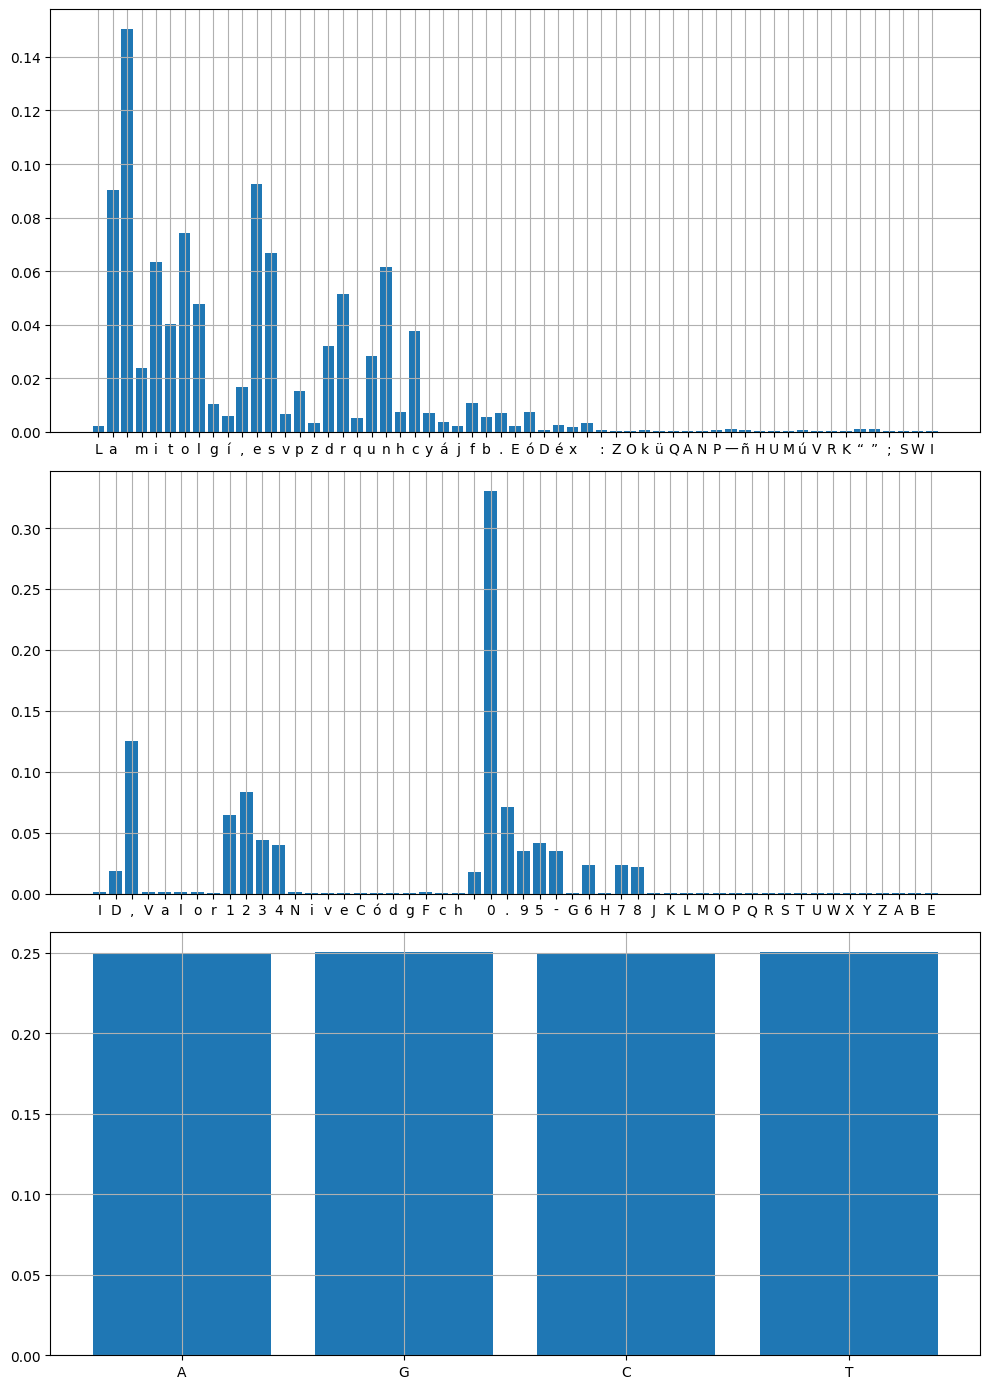

In [18]:
fig = plt.figure(figsize=(10,14))
idx = 311
for string in strings:
    pmf = char_pmf(string)
    pmf_chart(pmf, fig, idx)
    idx += 1
plt.tight_layout()
plt.show()

#### $\boldsymbol{(2)}$ Codificación de Huffman

#### ***Definición de Longitud Promedio***: 

Dado un alfabeto de una fuente $\mathbf{X}$ con $N$ símbolos únicos $\mathbf{X}=\{x_1,x_2,\dots,x_N\}$, donde cada símbolo $x_i$ tiene probabilidad $p(x_i)$ y se le asigna un código binario de longitud $\ell(x_i)$ bits, la longitud promedio $L$ se define como la esperanza de la longitud del código:

$$
L \;=\; \mathbb{E}\big[\ell(\mathbf{X})\big] \;=\; \sum_{i=1}^{N} p(x_i)\,\ell(x_i),
$$

sujeto a $\sum_{i=1}^{N} p(x_i)=1$.

- $L$: costo promedio en bits por símbolo (longitud media del código).



#### ***Definición: Cantidad de Bits para una Codificación Uniforme ($L_{\text{unif}}$)***

Si una fuente tiene $N$ símbolos únicos, necesitamos la menor cantidad entera de bits $k$ tal que se puedan formar al menos $N$ códigos binarios distintos. Como con $k$ bits se generan $2^{k}$ códigos, debe cumplirse:

$$
2^{k} \ge N
$$

Aplicando logaritmo en base 2 y tomando la función techo para obtener un entero:

$$
k \ge \log_{2}N \quad\Longrightarrow\quad L_{\text{unif}} = \left\lceil \log_{2} N \right\rceil
$$

Aquí $L_{\text{unif}}$ es la longitud uniforme mínima en bits por símbolo.


#### ***Definicion: Reducción de memoria (%)***

El porcentaje de reducción se calcula como la disminución fraccional en la longitud de bits, expresada como porcentaje. Aquí \(L\) es la longitud promedio (p. ej. Huffman) y \(L_{\text{unif}}\) la longitud uniforme mínima.

$$
\text{Reducción}(\%)=\frac{L_{\text{unif}}-L}{L_{\text{unif}}}\times 100
=\left(1-\frac{L}{L_{\text{unif}}}\right)\times 100
$$


In [ ]:
from math import ceil, log2 # ceil es la funcion techo, log2 es la funcion logaritmo en base 2, ambas utilez para calcular la cantidad de bits minima para representar los N digitos


pmfs = [char_pmf(s) for s in strings] # vector de pmf de cada texto
huffman_codes = [huffman_code(pmf) for pmf in pmfs] # vector de codigos de huffman para cada pmf

text_names = ['mitologia.txt', 'tabla.txt', 'adn.txt'] # orden de textos

print(f'DATOS OBTENIDOS\n')

for i, name in enumerate(text_names): 
    pmf=pmfs[i]
    huff_code = huffman_codes[i]

    # Parte (a): Longitud Promedio de Bits

    longitud_promedio_huffman = 0
    for char, prob in pmf.items():
        longitud_promedio_huffman += prob * len(huff_code[char])

    # Parte (b): Longitud de Bits para Codificacion Uniforme

    N_simbolos = len(pmf)
    longitud_uniforme = ceil(log2(N_simbolos))

    # Parte (c): Porcentaje de reduccion
    reduccion = (1 - (longitud_promedio_huffman / longitud_uniforme)) * 100

    # Esto lo podemos mejorar y convertir en una tabla con matplotlib 
    print(f"Resultados para '{name}':")
    print(f"  - Número de símbolos únicos (N): {N_simbolos}")
    print(f"  - Longitud Promedio (Huffman): {longitud_promedio_huffman:.4f} [bits/simbolo]")
    print(f"  - Longitud Uniforme Mínima: {longitud_uniforme} [bits/simbolo]")
    print(f"  - Reducción de memoria: {reduccion:.2f}%\n")

DATOS OBTENIDOS

Resultados para 'mitologia.txt':
  - Número de símbolos únicos (N): 59
  - Longitud Promedio (Huffman): 4.3662 [bits/simbolo]
  - Longitud Uniforme Mínima: 6 [bits/simbolo]
  - Reducción de memoria: 27.23%

Resultados para 'tabla.txt':
  - Número de símbolos únicos (N): 52
  - Longitud Promedio (Huffman): 3.5290 [bits/simbolo]
  - Longitud Uniforme Mínima: 6 [bits/simbolo]
  - Reducción de memoria: 41.18%

Resultados para 'adn.txt':
  - Número de símbolos únicos (N): 4
  - Longitud Promedio (Huffman): 2.0000 [bits/simbolo]
  - Longitud Uniforme Mínima: 2 [bits/simbolo]
  - Reducción de memoria: -0.00%



#### $\boldsymbol{(3)}$ $H(X):$ Entropía de los textos

#### $\boldsymbol{(4)}$ $\eta:$ Entropía normalizada

$$
\eta = \frac{H(X)}{\log_2(N)}, \quad {\small N: \text{cantidad de símbolos}}
$$